Backtesting: 100%|██████████| 1060/1060 [00:31<00:00, 33.59it/s]



--- PERFORMANCE SUMMARY ---
                 Active_Strategy  HRP_Bench  EF_Bench  1/N_Bench
Ann. Return (%)           22.518     17.642    30.540     23.248
Ann. Vol (%)              20.663     12.956    21.189     17.166
Sharpe Ratio               1.090      1.362     1.441      1.354
Max DD (%)               -38.978    -16.021   -28.177    -23.197


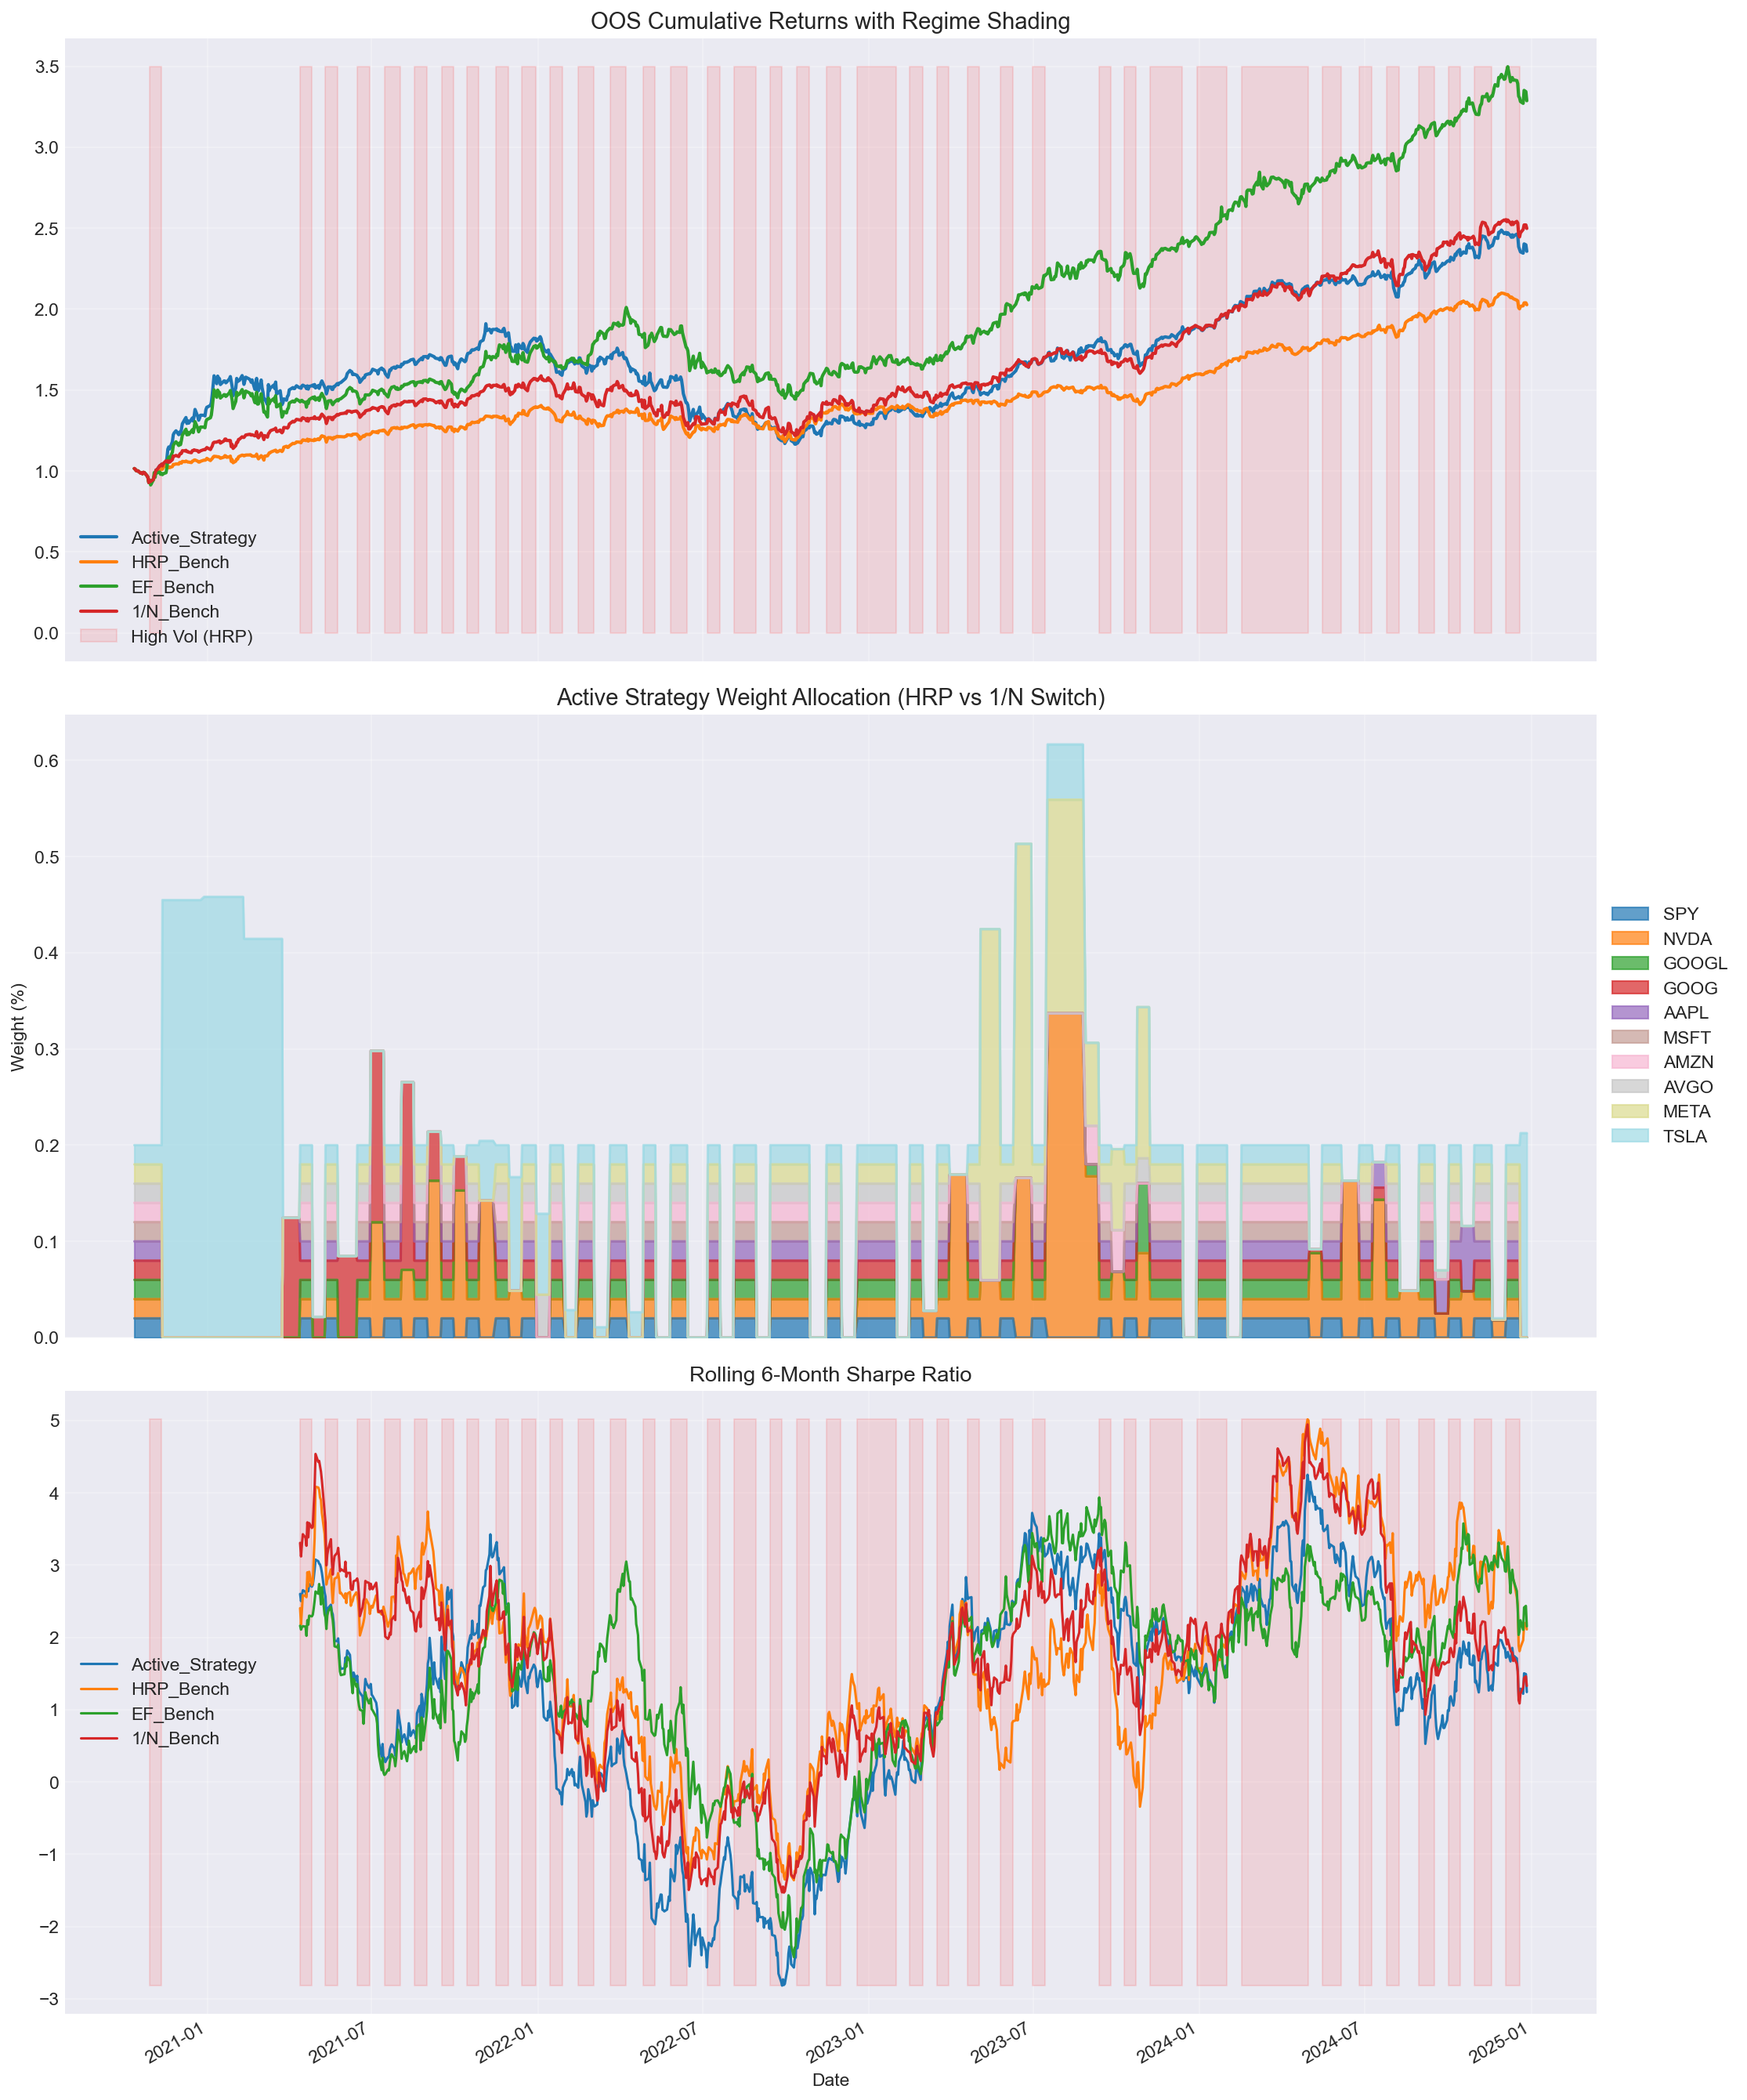

In [22]:
# %% [markdown]
# # HMM‑Driven Asset Allocation: HRP vs 1/N with Regime Switching
# 
# This notebook implements a dynamic strategy that switches between **Hierarchical Risk Parity (HRP)** and **1/N** based on a 2‑state HMM fitted to SPY returns (or mean market returns). Data is loaded from a single Excel file `test_assets.xlsx`.

# %%
%matplotlib inline
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from tqdm import tqdm
from numpy import linalg as la
from scipy.cluster.hierarchy import linkage
from hmmlearn import hmm
from pypfopt import EfficientFrontier, expected_returns

# --- CONFIGURATION ---
UNIVERSE_SIZE = 50          # Number of assets to use (first N columns after 'Date')
USE_SPY_ONLY_REGIME = True   # Use SPY returns for HMM regime detection
INDEX_TICKER = 'SPY'         # Must exist as a column in the Excel file
N_REB = 30                   # Minimum days between rebalancing
M_GAP = 10                   # Minimum days after a regime change before allowing rebalancing
HMM_WINDOW = 252             # Rolling window for HMM training
EST_WINDOW = 125             # Estimation window for covariance / expected returns

START_DATE = "2018-01-01"
END_DATE = "2025-06-01"

warnings.filterwarnings('ignore')

# --- MATH UTILITIES (HRP) ---
def nearestPD(A):
    B = (A + A.T) / 2
    _, s, V = la.svd(B)
    H = np.dot(V.T, np.dot(np.diag(s), V))
    A2 = (B + H) / 2
    A3 = (A2 + A2.T) / 2
    if isPD(A3): return A3
    spacing = np.spacing(la.norm(A))
    I = np.eye(A.shape[0]); k = 1
    while not isPD(A3):
        mineig = np.min(np.real(la.eigvals(A3)))
        A3 += I * (-mineig * k**2 + spacing)
        k += 1
    return A3

def isPD(B):
    try:
        _ = la.cholesky(B); return True
    except la.LinAlgError: return False

def get_quasi_diag(link):
    link = link.astype(int)
    sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]
    while sort_ix.max() >= num_items:
        sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
        df0 = sort_ix[sort_ix >= num_items]
        i, j = df0.index, df0.values - num_items
        sort_ix[i] = link[j, 0]
        df0 = pd.Series(link[j, 1], index=i + 1)
        sort_ix = pd.concat([sort_ix, df0]).sort_index()
        sort_ix.index = range(sort_ix.shape[0])
    return sort_ix.tolist()

def get_cluster_var(cov, c_items):
    cov_ = cov.iloc[c_items, c_items]
    ivp = 1. / (np.diag(cov_) + 1e-9)
    ivp /= ivp.sum()
    w_ = ivp.reshape(-1, 1)
    return np.dot(np.dot(w_.T, cov_.values), w_)[0, 0]

def get_rec_bipart(cov, sort_ix):
    w = pd.Series(1.0, index=sort_ix)
    c_items = [sort_ix]
    while len(c_items) > 0:
        c_items = [i[int(j):int(k)] for i in c_items for j, k in
                   ((0, len(i)/2), (len(i)/2, len(i))) if len(i) > 1]
        for i in range(0, len(c_items), 2):
            c_items0, c_items1 = c_items[i], c_items[i+1]
            v0, v1 = get_cluster_var(cov, c_items0), get_cluster_var(cov, c_items1)
            alpha = 1 - v0 / (v0 + v1 + 1e-12)
            w.loc[c_items0] *= alpha
            w.loc[c_items1] *= (1 - alpha)
    return w

# --- DATA LOADING (Single Excel file, universe slice) ---
def load_data(universe_size: int = 20):
    """
    Loads data from './data/test_assets.xlsx'.
    The file must have a 'Date' column (will be set as index) and asset columns.
    Returns:
        returns (pd.DataFrame): percentage changes, indexed by Date
        prices (pd.DataFrame): original price levels, indexed by Date
    """
    file_path = './data/assets.xlsx'
    df = pd.read_excel(file_path).set_index('Date')
    df.index = pd.to_datetime(df.index)
    
    # Select first `universe_size` columns as assets
    assets = df.iloc[:, :universe_size]
    returns = assets.pct_change().dropna()
    return returns, assets

# --- BACKTEST ENGINE ---
rets, prices = load_data(UNIVERSE_SIZE)

# Filter by date range
rets = rets.loc[START_DATE:END_DATE]
prices = prices.loc[START_DATE:END_DATE]

asset_names = rets.columns.tolist()

# Adjust HMM window if data is short
if len(rets) <= HMM_WINDOW + 50:
    HMM_WINDOW = int(len(rets) * 0.5)

start_idx = HMM_WINDOW + 20
history = {s: [] for s in ['Active_Strategy', 'HRP_Bench', 'EF_Bench', '1/N_Bench']}
weights_history = []
regime_track, reb_dates = [], []
last_reb_idx, current_regime = start_idx, 0
curr_weights = {s: pd.Series(1/len(asset_names), index=asset_names) for s in history.keys()}

# Ensure SPY exists if USE_SPY_ONLY_REGIME = True
if USE_SPY_ONLY_REGIME and INDEX_TICKER not in rets.columns:
    raise ValueError(f"Column '{INDEX_TICKER}' not found in the asset list. "
                     f"Available columns: {rets.columns.tolist()}")

for i in tqdm(range(start_idx, len(rets)), desc="Backtesting"):
    days_since = i - last_reb_idx

    # 1. HMM Regime Detection
    if USE_SPY_ONLY_REGIME:
        hmm_raw = rets[INDEX_TICKER].iloc[i-HMM_WINDOW:i].values.reshape(-1, 1)
    else:
        hmm_raw = rets.iloc[i-HMM_WINDOW:i].mean(axis=1).values.reshape(-1, 1)

    hmm_input = hmm_raw * 100
    model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=100, tol=0.1, random_state=42)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model.fit(hmm_input)

    high_vol_state = np.argmax([model.covars_[s][0][0] for s in range(2)])
    new_regime = 1 if model.predict(hmm_input)[-1] == high_vol_state else 0

    # 2. Rebalancing Trigger Logic
    reg_change = (new_regime != current_regime)
    do_reb = (days_since >= N_REB) or (reg_change and days_since >= M_GAP)

    if do_reb:
        look_rets = rets.iloc[i-EST_WINDOW:i]
        look_prices = prices.iloc[i-EST_WINDOW:i]
        cov = look_rets.cov()
        mu = expected_returns.mean_historical_return(look_prices)

        # --- HRP ---
        hrp_link = linkage(look_rets.corr(), 'single')
        w_hrp = get_rec_bipart(cov, get_quasi_diag(hrp_link))
        w_hrp.index = [asset_names[j] for j in w_hrp.index]
        w_hrp = w_hrp.reindex(asset_names).fillna(0)

        # --- Efficient Frontier (max Sharpe) - benchmark only ---
        try:
            ef = EfficientFrontier(mu, cov)
            ef.max_sharpe()
            w_ef = pd.Series(ef.clean_weights()).reindex(asset_names).fillna(0)
        except Exception:
            w_ef = pd.Series(1/len(asset_names), index=asset_names)

        # --- 1/N equal weight ---
        w_one_over_n = pd.Series(1/len(asset_names), index=asset_names)

        # Benchmarks
        curr_weights['HRP_Bench'] = w_hrp
        curr_weights['EF_Bench'] = w_ef
        curr_weights['1/N_Bench'] = w_one_over_n

        # Active Strategy: HRP in high-vol regime (1), 1/N in low-vol regime (0)
        curr_weights['Active_Strategy'] = w_one_over_n if new_regime == 1 else w_ef

        current_regime, last_reb_idx = new_regime, i
        reb_dates.append(rets.index[i])

    for s in history.keys():
        history[s].append((rets.iloc[i] * curr_weights[s]).sum())

    w_step = curr_weights['Active_Strategy'].copy()
    w_step['Date'] = rets.index[i]
    weights_history.append(w_step)
    regime_track.append(current_regime)

# --- PERFORMANCE SUMMARY ---
res_df = pd.DataFrame(history, index=rets.index[start_idx:])
stats = pd.DataFrame({
    'Ann. Return (%)': res_df.mean() * 252 * 100,
    'Ann. Vol (%)': res_df.std() * np.sqrt(252) * 100,
    'Sharpe Ratio': (res_df.mean() * 252) / (res_df.std() * np.sqrt(252)),
    'Max DD (%)': ((1+res_df).cumprod() / (1+res_df).cumprod().cummax() - 1).min() * 100
}).T
print("\n--- PERFORMANCE SUMMARY ---")
print(stats.round(3))

# --- PLOTTING ---
reg_s = pd.Series(regime_track, index=res_df.index)
w_df = pd.DataFrame(weights_history).set_index('Date')

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)

# Plot 1: Cumulative Returns
cum_rets = (1 + res_df).cumprod()
cum_rets.plot(ax=axes[0], lw=2)
axes[0].fill_between(reg_s.index, 0, cum_rets.max().max(), where=reg_s==1, color='red', alpha=0.1, label='High Vol (HRP)')
axes[0].set_title("OOS Cumulative Returns with Regime Shading", fontsize=14)
axes[0].legend()

# Plot 2: Active Strategy Weights Evolution (only top 10 assets for clarity)
w_df_subset = w_df.iloc[:, :min(10, len(w_df.columns))]
w_df_subset.clip(lower=0).plot.area(ax=axes[1], stacked=True, alpha=0.7, cmap='tab20')
axes[1].set_title("Active Strategy Weight Allocation (HRP vs 1/N Switch)", fontsize=14)
axes[1].set_ylabel("Weight (%)")
axes[1].legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

# Plot 3: Rolling Sharpe (6 months)
rs = (res_df.rolling(126).mean() / res_df.rolling(126).std()) * np.sqrt(252)
rs.plot(ax=axes[2], title="Rolling 6-Month Sharpe Ratio")
axes[2].fill_between(reg_s.index, rs.min().min(), rs.max().max(), where=reg_s==1, color='red', alpha=0.1)

plt.tight_layout()
plt.show()

Backtesting: 100%|██████████| 1060/1060 [00:33<00:00, 31.96it/s]



--- PERFORMANCE SUMMARY ---
                 Active_Strategy  HRP_Bench  EF_Bench  1/N_Bench
Ann. Return (%)           22.518     17.642    30.540     23.248
Ann. Vol (%)              20.663     12.956    21.189     17.166
Sharpe Ratio               1.090      1.362     1.441      1.354
Max DD (%)               -38.978    -16.021   -28.177    -23.197

--- Rolling Sharpe Crossovers (window=126) ---
HRP vs EF crossovers: 43 times
HRP rolling Sharpe > EF rolling Sharpe: 61.8% of the time


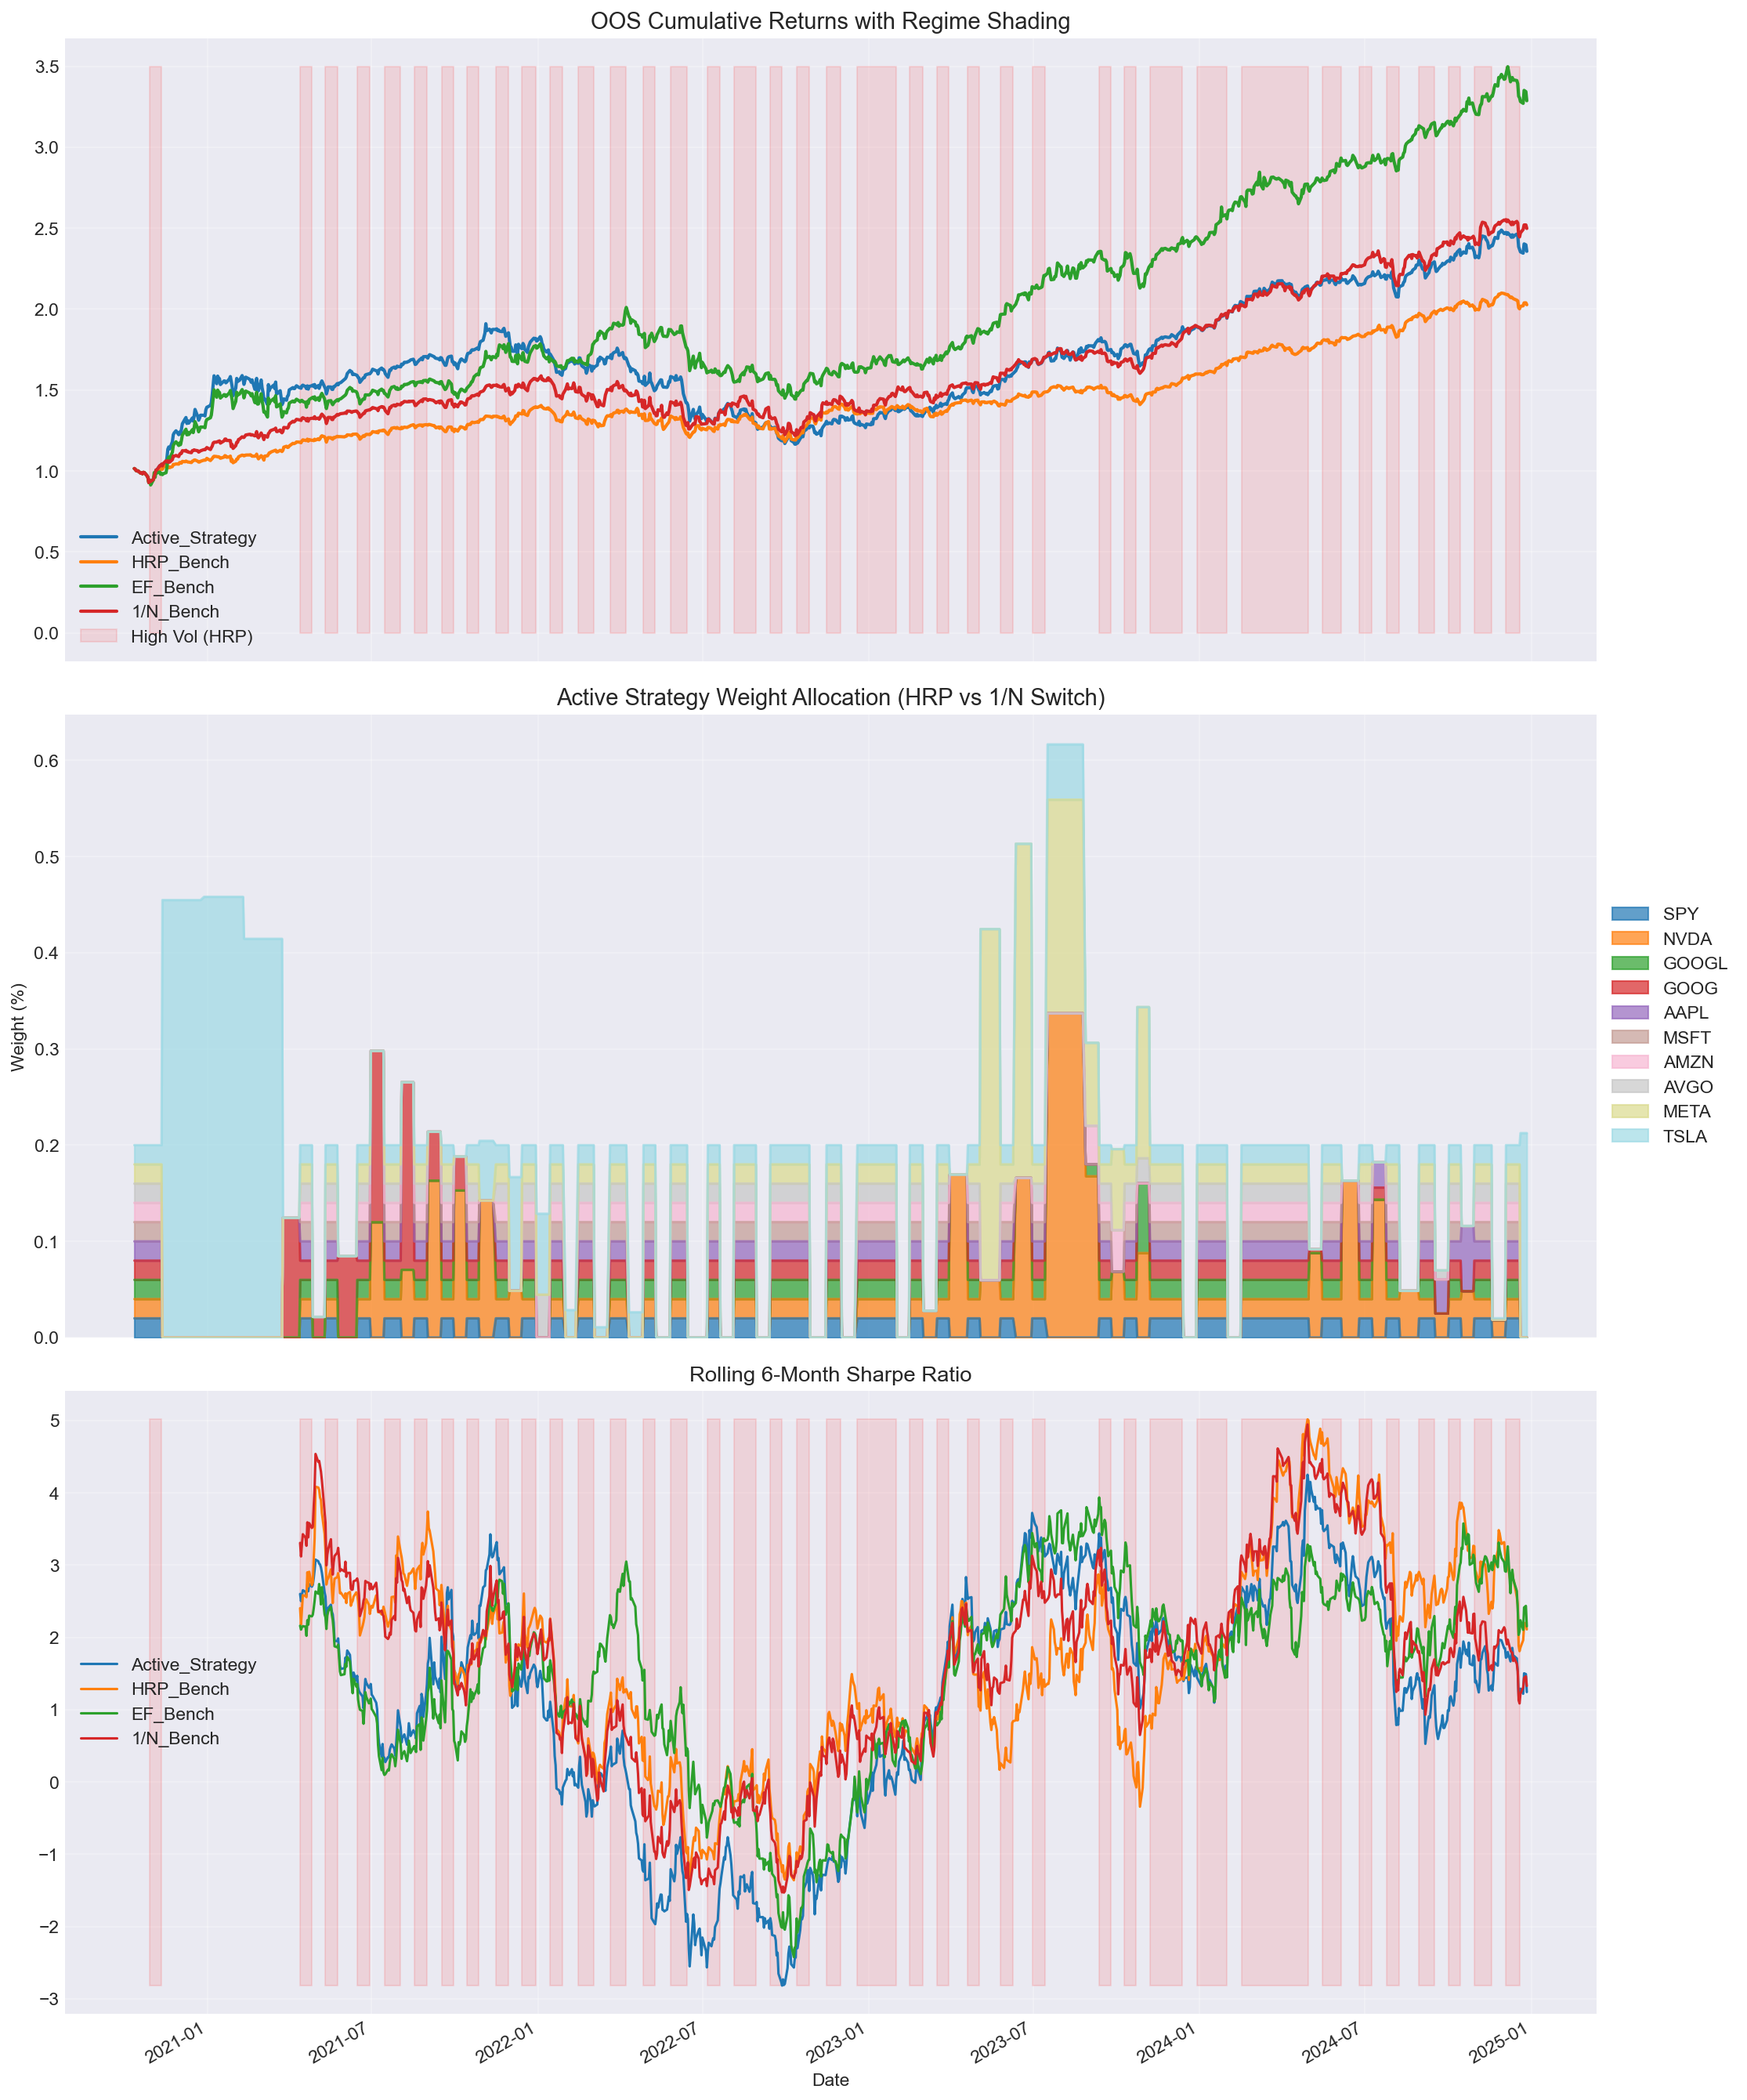

In [23]:
# %% [markdown]
# # HMM‑Driven Asset Allocation: HRP vs 1/N with Regime Switching
# 
# This notebook implements a dynamic strategy that switches between **Hierarchical Risk Parity (HRP)** and **1/N** based on a 2‑state HMM fitted to SPY returns (or mean market returns). Data is loaded from a single Excel file `assets.xlsx`.

# %%
%matplotlib inline
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from tqdm import tqdm
from numpy import linalg as la
from scipy.cluster.hierarchy import linkage
from hmmlearn import hmm
from pypfopt import EfficientFrontier, expected_returns

# --- CONFIGURATION ---
UNIVERSE_SIZE = 50          # Number of assets to use (first N columns after 'Date')
USE_SPY_ONLY_REGIME = True   # Use SPY returns for HMM regime detection
INDEX_TICKER = 'SPY'         # Must exist as a column in the Excel file
N_REB = 30                   # Minimum days between rebalancing
M_GAP = 10                   # Minimum days after a regime change before allowing rebalancing
HMM_WINDOW = 252             # Rolling window for HMM training
EST_WINDOW = 125             # Estimation window for covariance / expected returns

START_DATE = "2018-01-01"
END_DATE = "2025-06-01"

warnings.filterwarnings('ignore')

# --- MATH UTILITIES (HRP) ---
def nearestPD(A):
    B = (A + A.T) / 2
    _, s, V = la.svd(B)
    H = np.dot(V.T, np.dot(np.diag(s), V))
    A2 = (B + H) / 2
    A3 = (A2 + A2.T) / 2
    if isPD(A3): return A3
    spacing = np.spacing(la.norm(A))
    I = np.eye(A.shape[0]); k = 1
    while not isPD(A3):
        mineig = np.min(np.real(la.eigvals(A3)))
        A3 += I * (-mineig * k**2 + spacing)
        k += 1
    return A3

def isPD(B):
    try:
        _ = la.cholesky(B); return True
    except la.LinAlgError: return False

def get_quasi_diag(link):
    link = link.astype(int)
    sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]
    while sort_ix.max() >= num_items:
        sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
        df0 = sort_ix[sort_ix >= num_items]
        i, j = df0.index, df0.values - num_items
        sort_ix[i] = link[j, 0]
        df0 = pd.Series(link[j, 1], index=i + 1)
        sort_ix = pd.concat([sort_ix, df0]).sort_index()
        sort_ix.index = range(sort_ix.shape[0])
    return sort_ix.tolist()

def get_cluster_var(cov, c_items):
    cov_ = cov.iloc[c_items, c_items]
    ivp = 1. / (np.diag(cov_) + 1e-9)
    ivp /= ivp.sum()
    w_ = ivp.reshape(-1, 1)
    return np.dot(np.dot(w_.T, cov_.values), w_)[0, 0]

def get_rec_bipart(cov, sort_ix):
    w = pd.Series(1.0, index=sort_ix)
    c_items = [sort_ix]
    while len(c_items) > 0:
        c_items = [i[int(j):int(k)] for i in c_items for j, k in
                   ((0, len(i)/2), (len(i)/2, len(i))) if len(i) > 1]
        for i in range(0, len(c_items), 2):
            c_items0, c_items1 = c_items[i], c_items[i+1]
            v0, v1 = get_cluster_var(cov, c_items0), get_cluster_var(cov, c_items1)
            alpha = 1 - v0 / (v0 + v1 + 1e-12)
            w.loc[c_items0] *= alpha
            w.loc[c_items1] *= (1 - alpha)
    return w

# --- DATA LOADING (Single Excel file, universe slice) ---
def load_data(universe_size: int = 20):
    """
    Loads data from './data/assets.xlsx'.
    The file must have a 'Date' column (will be set as index) and asset columns.
    Returns:
        returns (pd.DataFrame): percentage changes, indexed by Date
        prices (pd.DataFrame): original price levels, indexed by Date
    """
    file_path = './data/assets.xlsx'
    df = pd.read_excel(file_path).set_index('Date')
    df.index = pd.to_datetime(df.index)
    
    # Select first `universe_size` columns as assets
    assets = df.iloc[:, :universe_size]
    returns = assets.pct_change().dropna()
    return returns, assets

# --- BACKTEST ENGINE ---
rets, prices = load_data(UNIVERSE_SIZE)

# Filter by date range
rets = rets.loc[START_DATE:END_DATE]
prices = prices.loc[START_DATE:END_DATE]

asset_names = rets.columns.tolist()

# Adjust HMM window if data is short
if len(rets) <= HMM_WINDOW + 50:
    HMM_WINDOW = int(len(rets) * 0.5)

start_idx = HMM_WINDOW + 20
history = {s: [] for s in ['Active_Strategy', 'HRP_Bench', 'EF_Bench', '1/N_Bench']}
weights_history = []
regime_track, reb_dates = [], []
last_reb_idx, current_regime = start_idx, 0
curr_weights = {s: pd.Series(1/len(asset_names), index=asset_names) for s in history.keys()}

# Ensure SPY exists if USE_SPY_ONLY_REGIME = True
if USE_SPY_ONLY_REGIME and INDEX_TICKER not in rets.columns:
    raise ValueError(f"Column '{INDEX_TICKER}' not found in the asset list. "
                     f"Available columns: {rets.columns.tolist()}")

for i in tqdm(range(start_idx, len(rets)), desc="Backtesting"):
    days_since = i - last_reb_idx

    # 1. HMM Regime Detection
    if USE_SPY_ONLY_REGIME:
        hmm_raw = rets[INDEX_TICKER].iloc[i-HMM_WINDOW:i].values.reshape(-1, 1)
    else:
        hmm_raw = rets.iloc[i-HMM_WINDOW:i].mean(axis=1).values.reshape(-1, 1)

    hmm_input = hmm_raw * 100
    model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=100, tol=0.1, random_state=42)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model.fit(hmm_input)

    high_vol_state = np.argmax([model.covars_[s][0][0] for s in range(2)])
    new_regime = 1 if model.predict(hmm_input)[-1] == high_vol_state else 0

    # 2. Rebalancing Trigger Logic
    reg_change = (new_regime != current_regime)
    do_reb = (days_since >= N_REB) or (reg_change and days_since >= M_GAP)

    if do_reb:
        look_rets = rets.iloc[i-EST_WINDOW:i]
        look_prices = prices.iloc[i-EST_WINDOW:i]
        cov = look_rets.cov()
        mu = expected_returns.mean_historical_return(look_prices)

        # --- HRP ---
        hrp_link = linkage(look_rets.corr(), 'single')
        w_hrp = get_rec_bipart(cov, get_quasi_diag(hrp_link))
        w_hrp.index = [asset_names[j] for j in w_hrp.index]
        w_hrp = w_hrp.reindex(asset_names).fillna(0)

        # --- Efficient Frontier (max Sharpe) - benchmark only ---
        try:
            ef = EfficientFrontier(mu, cov)
            ef.max_sharpe()
            w_ef = pd.Series(ef.clean_weights()).reindex(asset_names).fillna(0)
        except Exception:
            w_ef = pd.Series(1/len(asset_names), index=asset_names)

        # --- 1/N equal weight ---
        w_one_over_n = pd.Series(1/len(asset_names), index=asset_names)

        # Benchmarks
        curr_weights['HRP_Bench'] = w_hrp
        curr_weights['EF_Bench'] = w_ef
        curr_weights['1/N_Bench'] = w_one_over_n

        # Active Strategy: HRP in high-vol regime (1), 1/N in low-vol regime (0)
        curr_weights['Active_Strategy'] = w_one_over_n if new_regime == 1 else w_ef

        current_regime, last_reb_idx = new_regime, i
        reb_dates.append(rets.index[i])

    for s in history.keys():
        history[s].append((rets.iloc[i] * curr_weights[s]).sum())

    w_step = curr_weights['Active_Strategy'].copy()
    w_step['Date'] = rets.index[i]
    weights_history.append(w_step)
    regime_track.append(current_regime)

# --- PERFORMANCE SUMMARY ---
res_df = pd.DataFrame(history, index=rets.index[start_idx:])
stats = pd.DataFrame({
    'Ann. Return (%)': res_df.mean() * 252 * 100,
    'Ann. Vol (%)': res_df.std() * np.sqrt(252) * 100,
    'Sharpe Ratio': (res_df.mean() * 252) / (res_df.std() * np.sqrt(252)),
    'Max DD (%)': ((1+res_df).cumprod() / (1+res_df).cumprod().cummax() - 1).min() * 100
}).T
print("\n--- PERFORMANCE SUMMARY ---")
print(stats.round(3))

# --- CROSSOVER COUNT (HRP vs EF rolling Sharpe) ---
rolling_window = 126  # same as in the plot (6 months)
# Compute rolling Sharpe (annualized)
hrp_rolling_sharpe = (res_df['HRP_Bench'].rolling(rolling_window).mean() /
                      res_df['HRP_Bench'].rolling(rolling_window).std()) * np.sqrt(252)
ef_rolling_sharpe = (res_df['EF_Bench'].rolling(rolling_window).mean() /
                     res_df['EF_Bench'].rolling(rolling_window).std()) * np.sqrt(252)

# Drop NaN values at the beginning
valid_idx = hrp_rolling_sharpe.dropna().index
hrp_rs = hrp_rolling_sharpe[valid_idx]
ef_rs = ef_rolling_sharpe[valid_idx]

# Count crossovers: when the difference changes sign
diff = hrp_rs - ef_rs
crossovers = (np.diff(np.sign(diff)) != 0).sum()
better_hrp = (hrp_rs > ef_rs).mean() * 100

print(f"\n--- Rolling Sharpe Crossovers (window={rolling_window}) ---")
print(f"HRP vs EF crossovers: {crossovers} times")
print(f"HRP rolling Sharpe > EF rolling Sharpe: {better_hrp:.1f}% of the time")

# --- PLOTTING ---
reg_s = pd.Series(regime_track, index=res_df.index)
w_df = pd.DataFrame(weights_history).set_index('Date')

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)

# Plot 1: Cumulative Returns
cum_rets = (1 + res_df).cumprod()
cum_rets.plot(ax=axes[0], lw=2)
axes[0].fill_between(reg_s.index, 0, cum_rets.max().max(), where=reg_s==1, color='red', alpha=0.1, label='High Vol (HRP)')
axes[0].set_title("OOS Cumulative Returns with Regime Shading", fontsize=14)
axes[0].legend()

# Plot 2: Active Strategy Weights Evolution (only top 10 assets for clarity)
w_df_subset = w_df.iloc[:, :min(10, len(w_df.columns))]
w_df_subset.clip(lower=0).plot.area(ax=axes[1], stacked=True, alpha=0.7, cmap='tab20')
axes[1].set_title("Active Strategy Weight Allocation (HRP vs 1/N Switch)", fontsize=14)
axes[1].set_ylabel("Weight (%)")
axes[1].legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

# Plot 3: Rolling Sharpe (6 months)
rs = (res_df.rolling(rolling_window).mean() / res_df.rolling(rolling_window).std()) * np.sqrt(252)
rs.plot(ax=axes[2], title="Rolling 6-Month Sharpe Ratio")
axes[2].fill_between(reg_s.index, rs.min().min(), rs.max().max(), where=reg_s==1, color='red', alpha=0.1)

plt.tight_layout()
plt.show()

Backtest: 100%|██████████| 1124/1124 [00:04<00:00, 271.90it/s]



--- PERFORMANCE SUMMARY ---
                 Active     HRP      EF     1/N
Ann. Return (%)  23.449  18.825  34.866  23.697
Ann. Vol (%)     21.080  13.156  23.354  17.186
Sharpe Ratio      1.112   1.431   1.493   1.379
Max DD (%)      -23.170 -15.229 -23.170 -23.197

--- Rolling Sharpe Crossovers (6 months) ---
HRP vs EF crossovers: 63 times
HRP rolling Sharpe > EF rolling Sharpe: 51.7% of time


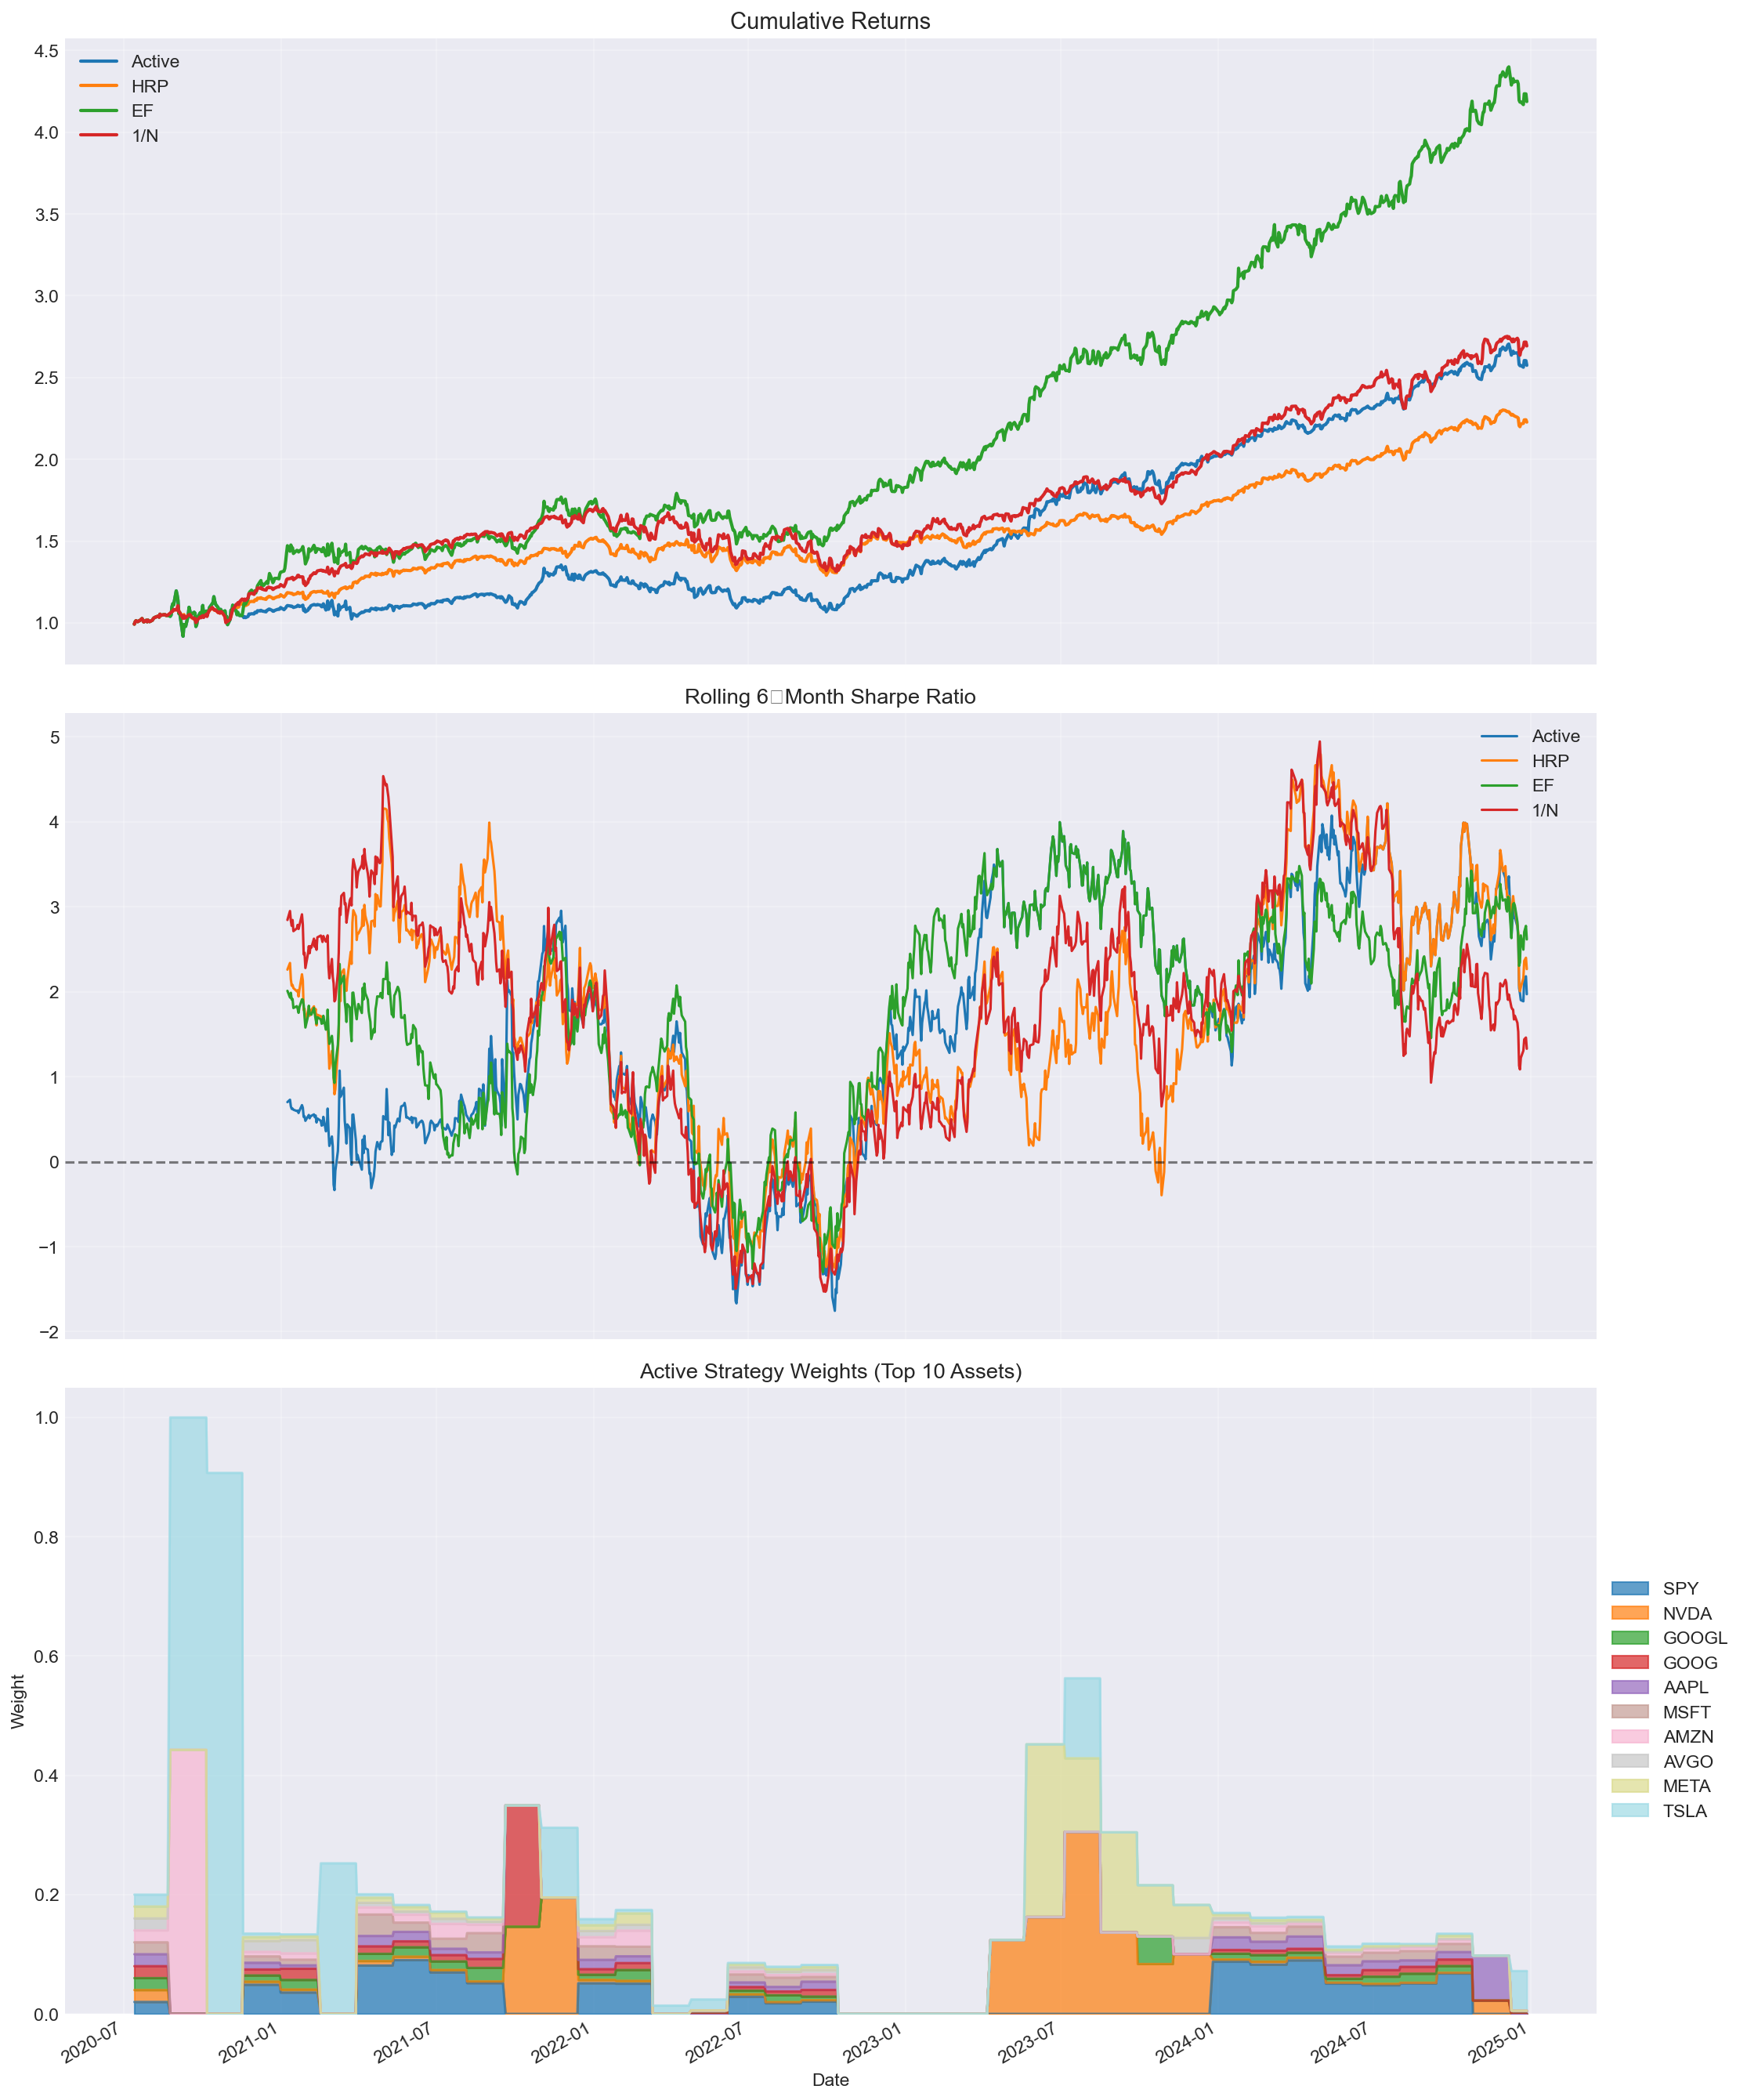

In [ ]:
# %% [markdown]
# # Rolling Sharpe‑Driven Asset Allocation: HRP vs EF
# 
# This notebook rebalances every `N_REB` days into the portfolio (HRP or EF) with the higher 3‑month rolling Sharpe ratio.

# %%
%matplotlib inline
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from tqdm import tqdm
from numpy import linalg as la
from scipy.cluster.hierarchy import linkage
from pypfopt import EfficientFrontier, expected_returns

# --- CONFIGURATION ---
UNIVERSE_SIZE = 50
N_REB = 30                   # rebalance every 30 days
SHARPE_LOOKBACK = 63         # 3 months
EST_WINDOW = 125
START_DATE = "2018-01-01"
END_DATE = "2025-06-01"

warnings.filterwarnings('ignore')

# --- HRP utilities (same as before) ---
def nearestPD(A):
    B = (A + A.T) / 2
    _, s, V = la.svd(B)
    H = np.dot(V.T, np.dot(np.diag(s), V))
    A2 = (B + H) / 2
    A3 = (A2 + A2.T) / 2
    if isPD(A3): return A3
    spacing = np.spacing(la.norm(A))
    I = np.eye(A.shape[0]); k = 1
    while not isPD(A3):
        mineig = np.min(np.real(la.eigvals(A3)))
        A3 += I * (-mineig * k**2 + spacing)
        k += 1
    return A3

def isPD(B):
    try:
        _ = la.cholesky(B); return True
    except la.LinAlgError: return False

def get_quasi_diag(link):
    link = link.astype(int)
    sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]
    while sort_ix.max() >= num_items:
        sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
        df0 = sort_ix[sort_ix >= num_items]
        i, j = df0.index, df0.values - num_items
        sort_ix[i] = link[j, 0]
        df0 = pd.Series(link[j, 1], index=i + 1)
        sort_ix = pd.concat([sort_ix, df0]).sort_index()
        sort_ix.index = range(sort_ix.shape[0])
    return sort_ix.tolist()

def get_cluster_var(cov, c_items):
    cov_ = cov.iloc[c_items, c_items]
    ivp = 1. / (np.diag(cov_) + 1e-9)
    ivp /= ivp.sum()
    w_ = ivp.reshape(-1, 1)
    return np.dot(np.dot(w_.T, cov_.values), w_)[0, 0]

def get_rec_bipart(cov, sort_ix):
    w = pd.Series(1.0, index=sort_ix)
    c_items = [sort_ix]
    while len(c_items) > 0:
        c_items = [i[int(j):int(k)] for i in c_items for j, k in
                   ((0, len(i)/2), (len(i)/2, len(i))) if len(i) > 1]
        for i in range(0, len(c_items), 2):
            c_items0, c_items1 = c_items[i], c_items[i+1]
            v0, v1 = get_cluster_var(cov, c_items0), get_cluster_var(cov, c_items1)
            alpha = 1 - v0 / (v0 + v1 + 1e-12)
            w.loc[c_items0] *= alpha
            w.loc[c_items1] *= (1 - alpha)
    return w

# --- DATA LOADING ---
def load_data(universe_size):
    file_path = './data/assets.xlsx'
    df = pd.read_excel(file_path).set_index('Date')
    df.index = pd.to_datetime(df.index)
    assets = df.iloc[:, :universe_size]
    returns = assets.pct_change().dropna()
    return returns, assets

rets, prices = load_data(UNIVERSE_SIZE)
rets = rets.loc[START_DATE:END_DATE]
prices = prices.loc[START_DATE:END_DATE]
asset_names = rets.columns.tolist()

# --- BACKTEST LOOP ---
start_idx = EST_WINDOW + SHARPE_LOOKBACK + 20
if start_idx >= len(rets):
    raise ValueError("Not enough data. Reduce windows.")

# We will store daily returns for each strategy
strategy_returns = {name: [] for name in ['Active', 'HRP', 'EF', '1/N']}
# Store weights at rebalance dates
active_weights_history = []
benchmark_weights = {'HRP': None, 'EF': None, '1/N': None}
last_reb_idx = start_idx

# Initial weights (until first rebalance)
current_active_weights = pd.Series(1/len(asset_names), index=asset_names)
current_hrp_weights = current_active_weights.copy()
current_ef_weights = current_active_weights.copy()
current_one_over_n = current_active_weights.copy()

for i in tqdm(range(start_idx, len(rets)), desc="Backtest"):
    days_since = i - last_reb_idx
    
    # Rebalance every N_REB days
    if days_since >= N_REB:
        # Estimate portfolios
        look_rets = rets.iloc[i-EST_WINDOW:i]
        look_prices = prices.iloc[i-EST_WINDOW:i]
        cov = look_rets.cov()
        mu = expected_returns.mean_historical_return(look_prices)
        
        # HRP
        hrp_link = linkage(look_rets.corr(), 'single')
        w_hrp = get_rec_bipart(cov, get_quasi_diag(hrp_link))
        w_hrp.index = [asset_names[j] for j in w_hrp.index]
        w_hrp = w_hrp.reindex(asset_names).fillna(0)
        
        # EF
        try:
            ef = EfficientFrontier(mu, cov)
            ef.max_sharpe()
            w_ef = pd.Series(ef.clean_weights()).reindex(asset_names).fillna(0)
        except:
            w_ef = pd.Series(1/len(asset_names), index=asset_names)
        
        # 1/N
        w_1n = pd.Series(1/len(asset_names), index=asset_names)
        
        # Update benchmark weights (they rebalance on same schedule for fair comparison)
        current_hrp_weights = w_hrp
        current_ef_weights = w_ef
        current_one_over_n = w_1n
        
        # --- Rolling Sharpe for HRP and EF (using their past daily returns) ---
        hrp_hist = np.array(strategy_returns['HRP'])
        ef_hist = np.array(strategy_returns['EF'])
        
        if len(hrp_hist) >= SHARPE_LOOKBACK:
            hrp_recent = hrp_hist[-SHARPE_LOOKBACK:]
            ef_recent = ef_hist[-SHARPE_LOOKBACK:]
            hrp_sharpe = (hrp_recent.mean() / hrp_recent.std()) * np.sqrt(252) if hrp_recent.std() != 0 else -np.inf
            ef_sharpe = (ef_recent.mean() / ef_recent.std()) * np.sqrt(252) if ef_recent.std() != 0 else -np.inf
        else:
            hrp_sharpe, ef_sharpe = -np.inf, 0  # default to EF
        
        # Choose active strategy
        if hrp_sharpe > ef_sharpe:
            current_active_weights = w_hrp
        else:
            current_active_weights = w_ef
        
        last_reb_idx = i
    
    # Compute daily returns for all strategies
    ret_today = rets.iloc[i]
    strategy_returns['Active'].append((ret_today * current_active_weights).sum())
    strategy_returns['HRP'].append((ret_today * current_hrp_weights).sum())
    strategy_returns['EF'].append((ret_today * current_ef_weights).sum())
    strategy_returns['1/N'].append((ret_today * current_one_over_n).sum())
    
    # Store active weights for later plotting (optional)
    active_weights_history.append(current_active_weights.copy())

# --- BUILD RESULTS DATAFRAME ---
res_df = pd.DataFrame(strategy_returns, index=rets.index[start_idx:])

# --- PERFORMANCE SUMMARY ---
stats = pd.DataFrame({
    'Ann. Return (%)': res_df.mean() * 252 * 100,
    'Ann. Vol (%)': res_df.std() * np.sqrt(252) * 100,
    'Sharpe Ratio': (res_df.mean() * 252) / (res_df.std() * np.sqrt(252)),
    'Max DD (%)': ((1+res_df).cumprod() / (1+res_df).cumprod().cummax() - 1).min() * 100
}).T
print("\n--- PERFORMANCE SUMMARY ---")
print(stats.round(3))

# --- ROLLING SHARPE CROSSOVERS (HRP vs EF) ---
rolling_window = 126  # 6 months for plot
hrp_rs = (res_df['HRP'].rolling(rolling_window).mean() / 
          res_df['HRP'].rolling(rolling_window).std()) * np.sqrt(252)
ef_rs = (res_df['EF'].rolling(rolling_window).mean() / 
         res_df['EF'].rolling(rolling_window).std()) * np.sqrt(252)
valid = hrp_rs.dropna().index
diff = hrp_rs[valid] - ef_rs[valid]
crossovers = (np.diff(np.sign(diff)) != 0).sum()
better_hrp = (hrp_rs[valid] > ef_rs[valid]).mean() * 100
print(f"\n--- Rolling Sharpe Crossovers (6 months) ---")
print(f"HRP vs EF crossovers: {crossovers} times")
print(f"HRP rolling Sharpe > EF rolling Sharpe: {better_hrp:.1f}% of time")

# --- PLOTTING ---
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)

# Cumulative returns
cum_rets = (1 + res_df).cumprod()
cum_rets.plot(ax=axes[0], lw=2)
axes[0].set_title("Cumulative Returns", fontsize=14)
axes[0].legend()

# Rolling Sharpe (6 months)
rs_all = (res_df.rolling(rolling_window).mean() / res_df.rolling(rolling_window).std()) * np.sqrt(252)
rs_all.plot(ax=axes[1], title="Rolling 6‑Month Sharpe Ratio")
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)

# Active weights evolution (first 10 assets)
w_df = pd.DataFrame([w.values for w in active_weights_history], 
                    columns=asset_names, index=res_df.index)
w_df.iloc[:, :10].clip(lower=0).plot.area(ax=axes[2], stacked=True, alpha=0.7, cmap='tab20')
axes[2].set_title("Active Strategy Weights (Top 10 Assets)")
axes[2].set_ylabel("Weight")
axes[2].legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

plt.tight_layout()
plt.show()

Backtesting: 100%|██████████| 461/461 [00:38<00:00, 11.93it/s]



--- OUT-OF-SAMPLE PERFORMANCE SUMMARY ---
                 Active_Strategy  MaxSharpe_Bench  MinVol_Bench  \
Ann. Return (%)            5.452           14.579         8.844   
Ann. Vol (%)              21.867           24.544        12.180   
Sharpe Ratio               0.249            0.594         0.726   
Max DD (%)               -29.023          -24.206       -11.780   

                 QuadUtil_Bench  1/N_Bench  
Ann. Return (%)          36.364     21.749  
Ann. Vol (%)             57.786     18.075  
Sharpe Ratio              0.629      1.203  
Max DD (%)              -57.381    -18.959  

Rebalances: 36 | High-vol days: 180 / 461


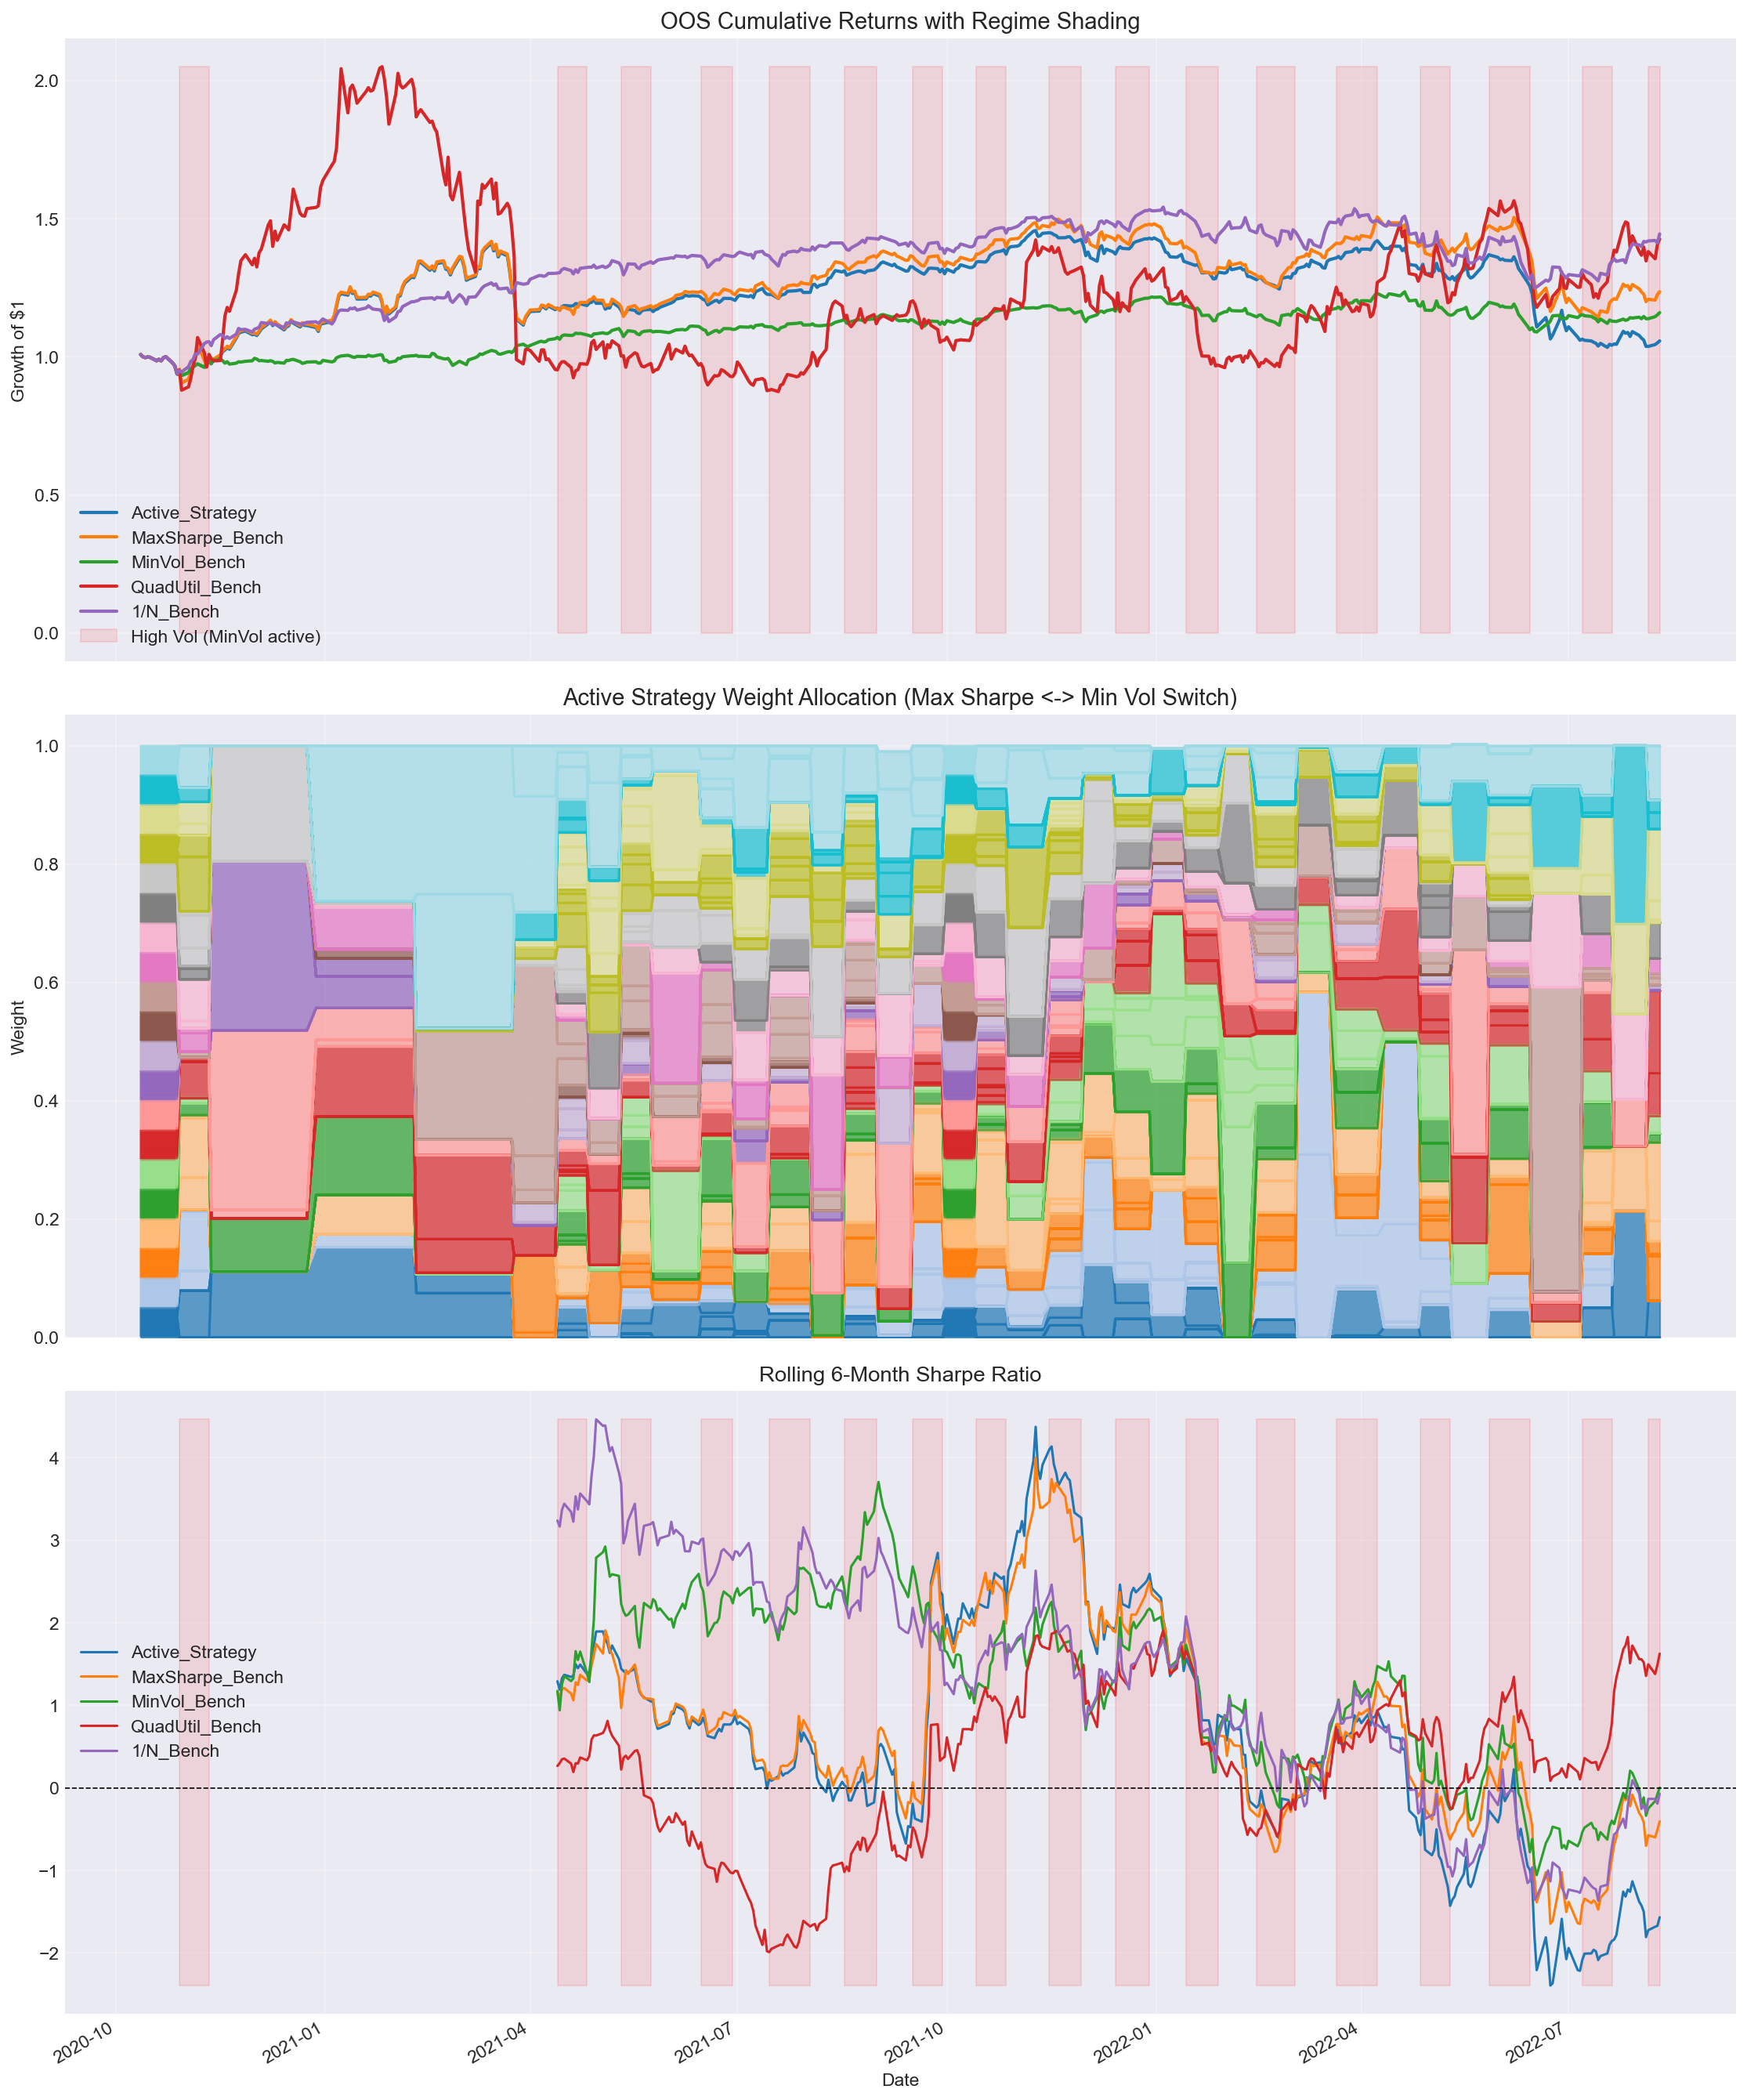

In [28]:
# Min vol + Max sharpe vs Quad utility and 1/N
"""
HMM Regime-Switching Portfolio: Max Sharpe (Low Vol) <-> Min Vol (High Vol)

Benchmarks (all out-of-sample, same rebalancing cadence):
  - MaxSharpe_Bench : pure max-Sharpe every rebalance
  - MinVol_Bench    : pure min-variance every rebalance
  - QuadUtil_Bench  : max quadratic utility (mean-variance with risk aversion)
  - 1/N_Bench       : equally weighted
"""

import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from tqdm import tqdm
from hmmlearn import hmm
from pypfopt import EfficientFrontier, expected_returns, risk_models

# --- CONFIGURATION ---
UNIVERSE_SIZE       = 300
USE_SPY_ONLY_REGIME = True
INDEX_TICKER        = 'SPY'
N_REB               = 30      # max days between rebalances
M_GAP               = 10      # min days between rebalances when regime flips
HMM_WINDOW          = 252
EST_WINDOW          = 125
RISK_AVERSION       = 3.0     # for quadratic-utility benchmark (higher = more risk-averse)

START_DATE = "2018-01-01"
END_DATE   = "2025-06-01"

warnings.filterwarnings('ignore')


# --- DATA LOADING ---
def load_data(universe_size: int = 20):
    drivers = pd.read_excel(r'./data/sensitivity_drivers.xlsx')
    assets  = pd.read_excel(r'./data/assets.xlsx')
    drivers['Date'] = pd.to_datetime(drivers['Date'].astype(str))
    assets['Date']  = pd.to_datetime(assets['Date'].astype(str))
    drivers = drivers.set_index("Date")
    assets  = assets.set_index("Date").iloc[:, :universe_size]
    returns = assets.pct_change().dropna()
    full_df = pd.merge(drivers, returns, left_index=True, right_index=True, how='inner')
    return full_df[returns.columns], full_df[drivers.columns], assets.reindex(full_df.index)


# --- PORTFOLIO CONSTRUCTORS (each returns a pd.Series reindexed to asset_names) ---
def _equal_weight(asset_names):
    return pd.Series(1.0 / len(asset_names), index=asset_names)

def build_max_sharpe(mu, cov, asset_names):
    try:
        ef = EfficientFrontier(mu, cov)
        ef.max_sharpe()
        return pd.Series(ef.clean_weights()).reindex(asset_names).fillna(0)
    except Exception:
        return _equal_weight(asset_names)

def build_min_vol(cov, asset_names):
    try:
        # min_volatility doesn't require mu; pypfopt still wants it though
        dummy_mu = pd.Series(0.0, index=cov.columns)
        ef = EfficientFrontier(dummy_mu, cov)
        ef.min_volatility()
        return pd.Series(ef.clean_weights()).reindex(asset_names).fillna(0)
    except Exception:
        return _equal_weight(asset_names)

def build_quad_utility(mu, cov, asset_names, risk_aversion=RISK_AVERSION):
    try:
        ef = EfficientFrontier(mu, cov)
        ef.max_quadratic_utility(risk_aversion=risk_aversion)
        return pd.Series(ef.clean_weights()).reindex(asset_names).fillna(0)
    except Exception:
        return _equal_weight(asset_names)


# --- BACKTEST ENGINE ---
rets, drivers, prices = load_data(UNIVERSE_SIZE)
rets    = rets.loc[START_DATE:END_DATE]
drivers = drivers.loc[START_DATE:END_DATE]
prices  = prices.loc[START_DATE:END_DATE]

asset_names = rets.columns.tolist()
if len(rets) <= HMM_WINDOW + 50:
    HMM_WINDOW = int(len(rets) * 0.5)

start_idx       = HMM_WINDOW + 20
strategy_names  = ['Active_Strategy', 'MaxSharpe_Bench', 'MinVol_Bench', 'QuadUtil_Bench', '1/N_Bench']
history         = {s: [] for s in strategy_names}
weights_history = []
regime_track    = []
reb_dates       = []
last_reb_idx    = start_idx
current_regime  = 0
curr_weights    = {s: _equal_weight(asset_names) for s in strategy_names}

for i in tqdm(range(start_idx, len(rets)), desc="Backtesting"):
    days_since = i - last_reb_idx

    # 1. HMM Regime Detection (fit on rolling window, predict last state)
    if USE_SPY_ONLY_REGIME:
        hmm_raw = rets[INDEX_TICKER].iloc[i - HMM_WINDOW:i].values.reshape(-1, 1)
    else:
        hmm_raw = rets.iloc[i - HMM_WINDOW:i].mean(axis=1).values.reshape(-1, 1)

    hmm_input = hmm_raw * 100
    model = hmm.GaussianHMM(n_components=2, covariance_type="full",
                            n_iter=100, tol=0.1, random_state=42)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model.fit(hmm_input)

    # label the state with higher variance as "high-vol"
    high_vol_state = int(np.argmax([model.covars_[s][0][0] for s in range(2)]))
    new_regime     = 1 if model.predict(hmm_input)[-1] == high_vol_state else 0

    # 2. Rebalance trigger: periodic OR regime flip (with min gap)
    reg_change = (new_regime != current_regime)
    do_reb     = (days_since >= N_REB) or (reg_change and days_since >= M_GAP)

    if do_reb:
        look_rets   = rets.iloc[i - EST_WINDOW:i]
        look_prices = prices.iloc[i - EST_WINDOW:i]

        # Expected returns & covariance (shrunk cov is more stable for MV optim)
        mu  = expected_returns.mean_historical_return(look_prices)
        try:
            cov = risk_models.CovarianceShrinkage(look_prices).ledoit_wolf()
        except Exception:
            cov = look_rets.cov()

        # Build all four "pure" sleeves at this rebalance
        w_ms  = build_max_sharpe(mu, cov, asset_names)
        w_mv  = build_min_vol(cov, asset_names)
        w_qu  = build_quad_utility(mu, cov, asset_names)
        w_1n  = _equal_weight(asset_names)

        curr_weights['MaxSharpe_Bench'] = w_ms
        curr_weights['MinVol_Bench']    = w_mv
        curr_weights['QuadUtil_Bench']  = w_qu
        curr_weights['1/N_Bench']       = w_1n

        # ACTIVE: Min Vol in high-vol regime, Max Sharpe in low-vol regime
        curr_weights['Active_Strategy'] = w_mv if new_regime == 1 else w_ms

        current_regime = new_regime
        last_reb_idx   = i
        reb_dates.append(rets.index[i])

    # Accrue daily P&L for every strategy using held weights
    for s in strategy_names:
        history[s].append((rets.iloc[i] * curr_weights[s]).sum())

    w_step = curr_weights['Active_Strategy'].copy()
    w_step['Date'] = rets.index[i]
    weights_history.append(w_step)
    regime_track.append(current_regime)


# --- PERFORMANCE SUMMARY ---
res_df = pd.DataFrame(history, index=rets.index[start_idx:])

ann_ret = res_df.mean() * 252
ann_vol = res_df.std()  * np.sqrt(252)
sharpe  = ann_ret / ann_vol
cum     = (1 + res_df).cumprod()
max_dd  = (cum / cum.cummax() - 1).min()

stats = pd.DataFrame({
    'Ann. Return (%)': ann_ret * 100,
    'Ann. Vol (%)'   : ann_vol * 100,
    'Sharpe Ratio'   : sharpe,
    'Max DD (%)'     : max_dd * 100,
}).T

print("\n--- OUT-OF-SAMPLE PERFORMANCE SUMMARY ---")
print(stats.round(3))
print(f"\nRebalances: {len(reb_dates)} | High-vol days: {sum(regime_track)} / {len(regime_track)}")


# --- PLOTTING ---
reg_s = pd.Series(regime_track, index=res_df.index)
w_df  = pd.DataFrame(weights_history).set_index('Date')

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)

# Plot 1: Cumulative Returns with regime shading
cum_rets = (1 + res_df).cumprod()
cum_rets.plot(ax=axes[0], lw=2)
axes[0].fill_between(reg_s.index, 0, cum_rets.max().max(),
                     where=reg_s == 1, color='red', alpha=0.1,
                     label='High Vol (MinVol active)')
axes[0].set_title("OOS Cumulative Returns with Regime Shading", fontsize=14)
axes[0].set_ylabel("Growth of $1")
axes[0].legend()

# Plot 2: Active strategy weights evolution
w_df.clip(lower=0).plot.area(ax=axes[1], stacked=True, alpha=0.7, cmap='tab20',
                             legend=False)
axes[1].set_title("Active Strategy Weight Allocation (Max Sharpe <-> Min Vol Switch)",
                  fontsize=14)
axes[1].set_ylabel("Weight")

# Plot 3: Rolling 6-month Sharpe
rs = (res_df.rolling(126).mean() / res_df.rolling(126).std()) * np.sqrt(252)
rs.plot(ax=axes[2], title="Rolling 6-Month Sharpe Ratio")
axes[2].fill_between(reg_s.index, rs.min().min(), rs.max().max(),
                     where=reg_s == 1, color='red', alpha=0.1)
axes[2].axhline(0, color='black', lw=0.8, ls='--')

plt.tight_layout()
plt.show()